# Player Categorizing Model
### K-Means Clustering via **PySpark RDD MapReduce**
**Labels:** Elite | Star | Reliable Player | Squad Player | Low Impact

---
**Pipeline:**
1. Environment Setup & Spark Session
2. Data Loading & Preprocessing
3. Feature Engineering
4. Preprocessing for MapReduce (Scale → TSV)
5. PySpark RDD K-Means MapReduce  ← *replaces Hadoop Streaming*
6. Label Assignment
7. Evaluation & Visualization

In [9]:
import shutil
shutil.copy(
    '/kaggle/input/datasets/alibahr/kmeans-spark-module/kmeans_spark.py',
    '/kaggle/working/kmeans_spark.py'
)
print("✓ kmeans_spark.py ready")

✓ kmeans_spark.py ready


## Step 1: Environment Setup & Spark Session

In [10]:
%pip install pyspark findspark pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("PlayerCategorizing_KMeans")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"✓ Spark {spark.version} ready")

✓ Spark 4.0.2 ready


## Step 2: Data Loading & Preprocessing

In [12]:
import os
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = '/kaggle/input/datasets/xfkzujqjvx97n/football-datasets'
OUTPUT_DIR = 'PreProcessedData'

if os.path.exists(OUTPUT_DIR):
    import shutil
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

END_SEASON = 2026

dataset = {
    'player_profiles'            : f'{DATA_DIR}/player_profiles/player_profiles.csv',
    'transfer_history'           : f'{DATA_DIR}/transfer_history/transfer_history.csv',
    'player_performances'        : f'{DATA_DIR}/player_performances/player_performances.csv',
    'player_national_performances': f'{DATA_DIR}/player_national_performances/player_national_performances.csv',
}

print(f"Data directory  : {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory  : /kaggle/input/datasets/xfkzujqjvx97n/football-datasets
Output directory: PreProcessedData


In [13]:
# ── Column selection per table ────────────────────────────────────────────────
COLUMNS = {
    'player_profiles': ['player_id', 'player_slug'],
    'transfer_history': ['player_id', 'transfer_date', 'from_team_id', 'to_team_id'],
    'player_performances': [
        'player_id', 'season_name', 'nb_in_group', 'nb_on_pitch', 'goals',
        'assists', 'own_goals', 'yellow_cards', 'second_yellow_cards',
        'direct_red_cards', 'penalty_goals', 'minutes_played',
        'goals_conceded', 'clean_sheets'
    ],
    'player_national_performances': ['player_id', 'matches', 'goals'],
}

# ── Helper functions ──────────────────────────────────────────────────────────
def is_date_column(col_name):
    keywords = ['date', 'day', 'dob', 'from', 'to', 'since', 'until', 'start', 'end']
    return any(k in col_name.lower() for k in keywords)

def clean_string_series(s):
    return s.astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

def coerce_numeric(s):
    cleaned = s.astype(str).str.replace(',', '', regex=False).str.replace(r'[^0-9.+-]', '', regex=True)
    return pd.to_numeric(cleaned, errors='coerce')

def extract_season_id_from_transfer_date(df):
    df = df.copy()
    df['transfer_date'] = pd.to_datetime(df['transfer_date'], errors='coerce')
    df = df.dropna(subset=['transfer_date'])
    df['season_id'] = df['transfer_date'].dt.year
    df.loc[df['transfer_date'].dt.month != 1, 'season_id'] += 1
    df['season_id'] = df['season_id'].astype(int)
    return df[df['season_id'] <= END_SEASON]

def extract_season_year_from_season_name(df):
    df = df.copy()
    if 'season_name' not in df.columns:
        return df
    season_raw = df['season_name'].astype('string').str.strip().dropna()
    season_pair = season_raw.str.extract(r'(?P<start>\d{2})[/-](?P<end>\d{2})')
    df['season_year'] = pd.to_numeric(season_pair['end'], errors='coerce') + 2000
    df = df.dropna(subset=['season_year'])
    df['season_year'] = df['season_year'].astype(int)
    df = df.drop(columns=['season_name'], errors='ignore')
    return df[df['season_year'] <= END_SEASON]

def preprocess_table(name, path):
    df = pd.read_csv(path)
    df = df[COLUMNS.get(name, [])]
    for col_name in df.columns:
        if df[col_name].dtype == 'object':
            if is_date_column(col_name):
                df[col_name] = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True)
            elif col_name == 'season_name':
                df[col_name] = clean_string_series(df[col_name])
            else:
                num = coerce_numeric(df[col_name])
                df[col_name] = num if num.notna().mean() >= 0.7 else clean_string_series(df[col_name])
    if name == 'transfer_history':
        df = extract_season_id_from_transfer_date(df)
    elif name == 'player_performances':
        df = extract_season_year_from_season_name(df)
    out = os.path.join(OUTPUT_DIR, name, f'{name}.csv')
    os.makedirs(os.path.dirname(out), exist_ok=True)
    df.to_csv(out, index=False)
    print(f'✓ {name}: {len(df):,} rows saved')
    return df

dfs = {}
for name, path in dataset.items():
    if os.path.exists(path):
        dfs[name] = preprocess_table(name, path)
    else:
        print(f'⚠ Warning: {path} not found')

print('\n✓ All tables loaded and preprocessed')

✓ player_profiles: 92,671 rows saved
✓ transfer_history: 1,098,155 rows saved
✓ player_performances: 1,500,525 rows saved
✓ player_national_performances: 92,701 rows saved

✓ All tables loaded and preprocessed


## Step 3: Feature Engineering
Aggregate player stats across all seasons and compute a single feature row per player.

In [14]:
def build_last_n_transfer_features(transfer_df, n=3):
    if transfer_df.empty:
        return pd.DataFrame(columns=['player_id'])
    working = transfer_df.copy()
    working['transfer_date'] = pd.to_datetime(working['transfer_date'], errors='coerce')
    working = working.sort_values(['player_id', 'transfer_date'], ascending=[True, False])
    available = [c for c in ['from_team_id', 'to_team_id'] if c in working.columns]
    frames = []
    for rank in range(1, n + 1):
        ranked = working.groupby('player_id').nth(rank - 1).reset_index()
        if ranked.empty:
            continue
        ranked = ranked[['player_id'] + available].rename(
            columns={c: f'move_{rank}_{c}' for c in available})
        frames.append(ranked)
    if not frames:
        return pd.DataFrame(columns=['player_id'])
    merged = frames[0]
    for f in frames[1:]:
        merged = merged.merge(f, on='player_id', how='outer')
    return merged

def build_total_performance_features(perf_df):
    exclude = {'player_id', 'season_name', 'season_year', 'competition_id',
               'competition_name', 'team_id', 'team_name'}
    num_cols = [c for c in perf_df.columns
                if c not in exclude and pd.api.types.is_numeric_dtype(perf_df[c])]
    if not num_cols:
        return pd.DataFrame(columns=['player_id'])
    totals = perf_df.groupby('player_id')[num_cols].sum(min_count=1).reset_index()
    return totals.rename(columns={c: f'{c}_total' for c in num_cols})

# Build features
profiles_df   = dfs['player_profiles'].copy()
transfer_df   = dfs['transfer_history'].copy()
perf_df       = dfs['player_performances'].copy()
nat_df        = dfs['player_national_performances'].copy()

print("Building transfer features...")
last_3_moves_df = build_last_n_transfer_features(transfer_df, n=3)

print("Building performance totals...")
total_perf_df = build_total_performance_features(perf_df)

print("Building national performance totals...")
nat_perf_df = (
    nat_df.groupby('player_id')[['matches', 'goals']].sum().reset_index()
    .rename(columns={'matches': 'national_matches_total', 'goals': 'national_goals_total'})
)

# Merge all
X_df = profiles_df.copy()
X_df = X_df.merge(last_3_moves_df, on='player_id', how='left')
X_df = X_df.merge(total_perf_df,   on='player_id', how='left')
X_df = X_df.merge(nat_perf_df,     on='player_id', how='left')

perf_cols = [c for c in total_perf_df.columns if c != 'player_id']
nat_cols  = [c for c in nat_perf_df.columns  if c != 'player_id']
X_df[perf_cols + nat_cols] = X_df[perf_cols + nat_cols].fillna(0)

X_df.to_csv(f'{OUTPUT_DIR}/final_model_features.csv', index=False)
print(f"\n✓ Feature matrix: {X_df.shape}")
X_df.head()

Building transfer features...
Building performance totals...
Building national performance totals...

✓ Feature matrix: (92671, 22)


,player_id,player_slug,move_1_from_team_id,move_1_to_team_id,move_2_from_team_id,move_2_to_team_id,move_3_from_team_id,move_3_to_team_id,nb_in_group_total,nb_on_pitch_total,...,own_goals_total,yellow_cards_total,second_yellow_cards_total,direct_red_cards_total,penalty_goals_total,minutes_played_total,goals_conceded_total,clean_sheets_total,national_matches_total,national_goals_total
0,1,silvio-adzic,58701.0,123.0,2195.0,58701.0,4825.0,2195.0,273.0,225.0,...,0.0,20.0,1.0,3.0,3.0,4372.0,0.0,0.0,23.0,11.0
1,100011,everton-silva,31428.0,515.0,62794.0,31428.0,38023.0,62794.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10,miroslav-klose,398.0,123.0,27.0,398.0,86.0,27.0,685.0,650.0,...,1.0,66.0,3.0,1.0,11.0,8184.0,0.0,0.0,137.0,71.0
3,10001,john-thompson,3820.0,123.0,1045.0,3820.0,1078.0,1045.0,385.0,301.0,...,0.0,50.0,0.0,2.0,0.0,5375.0,0.0,0.0,14.0,0.0
4,100001,carlos-auzqui,11470.0,14554.0,1775.0,11470.0,279.0,1775.0,63.0,37.0,...,0.0,6.0,0.0,0.0,0.0,732.0,0.0,0.0,0.0,0.0


## Step 4: Preprocessing for PySpark MapReduce
Select features → StandardScale → export to **TSV** (the input format for the RDD pipeline).

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

CANDIDATE_FEATURES = [
    'nb_on_pitch_total',
    'minutes_played_total',
    'goals_total',
    'assists_total',
    'penalty_goals_total',
    'clean_sheets_total',
    'goals_conceded_total',
    'yellow_cards_total',
    'national_matches_total',
    'national_goals_total',
]
CLUSTERING_FEATURES = [f for f in CANDIDATE_FEATURES if f in X_df.columns]
print(f"✓ Clustering features ({len(CLUSTERING_FEATURES)}):")
for f in CLUSTERING_FEATURES:
    print(f"   • {f}")

# Remove inactive players (all zeros)
feature_matrix = X_df[['player_id'] + CLUSTERING_FEATURES].copy().fillna(0)
active_mask    = feature_matrix[CLUSTERING_FEATURES].sum(axis=1) > 0
feature_matrix = feature_matrix[active_mask].reset_index(drop=True)
print(f"\n✓ Active players: {len(feature_matrix):,}")

# StandardScale
scaler       = StandardScaler()
scaled_vals  = scaler.fit_transform(feature_matrix[CLUSTERING_FEATURES])
scaled_df    = pd.DataFrame(scaled_vals, columns=CLUSTERING_FEATURES)
scaled_df.insert(0, 'player_id', feature_matrix['player_id'].values)
print("✓ StandardScaler applied")
scaled_df.describe().round(3)

✓ Clustering features (10):
   • nb_on_pitch_total
   • minutes_played_total
   • goals_total
   • assists_total
   • penalty_goals_total
   • clean_sheets_total
   • goals_conceded_total
   • yellow_cards_total
   • national_matches_total
   • national_goals_total

✓ Active players: 81,256
✓ StandardScaler applied


,player_id,nb_on_pitch_total,minutes_played_total,goals_total,assists_total,penalty_goals_total,clean_sheets_total,goals_conceded_total,yellow_cards_total,national_matches_total,national_goals_total
count,81256.000,81256.000,81256.000,81256.000,81256.000,81256.000,81256.000,81256.000,81256.000,81256.000,81256.000
mean,439999.582,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000
std,367174.968,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,1.000,-1.074,-0.755,-0.572,-0.550,-0.346,-0.208,-0.226,-0.855,-0.387,-0.227
25%,102252.000,-0.819,-0.655,-0.572,-0.550,-0.346,-0.208,-0.226,-0.732,-0.387,-0.227
50%,357161.500,-0.302,-0.319,-0.398,-0.418,-0.346,-0.208,-0.226,-0.362,-0.387,-0.227
75%,707431.250,0.590,0.286,0.089,0.108,-0.103,-0.208,-0.226,0.378,-0.219,-0.227
max,1453181.000,6.352,14.434,26.870,21.884,36.959,22.222,14.809,9.213,14.008,40.713


In [16]:
MR_DIR    = 'SparkKMeans'
INPUT_DIR = f'{MR_DIR}/input'
os.makedirs(INPUT_DIR, exist_ok=True)

# Export as TSV — tab-separated, no header, no player_id
# This is the same format mapper.py / kmeans_spark.py expect
TSV_PATH = f'{INPUT_DIR}/data.tsv'
scaled_df[CLUSTERING_FEATURES].to_csv(TSV_PATH, sep='\t', index=False, header=False)

# Save player_id order so we can re-attach labels after clustering
scaled_df[['player_id']].to_csv(f'{MR_DIR}/player_id_index.csv', index=True)

print(f"✓ TSV written → {TSV_PATH}  ({len(scaled_df):,} rows × {len(CLUSTERING_FEATURES)} features)")
print("\nFirst 3 lines of data.tsv:")
with open(TSV_PATH) as fh:
    for i, line in enumerate(fh):
        if i == 3: break
        print('  ' + ' | '.join(line.strip().split('\t')[:5]) + ' ...')

✓ TSV written → SparkKMeans/input/data.tsv  (81,256 rows × 10 features)

First 3 lines of data.tsv:
  0.5188440635286654 | 0.02233303482208904 | 1.61955577389462 | -0.22072901918925303 | 0.38112037469468857 ...
  3.527450629745257 | 0.7001267410620033 | 8.36684050120181 | 8.529157657593343 | 2.319032307623874 ...
  1.0568537083109264 | 0.20067172510504655 | -0.2585544079331545 | -0.3523062624491417 | -0.34559660015375593 ...


## Step 5: PySpark RDD K-Means MapReduce (K = 5)

We import `kmeans_spark.py` which contains the same **Map** and **Reduce** logic as `mapper.py` / `reducer.py`, now running natively inside PySpark RDD transformations.

```
Each iteration:
  RDD.map(mapper)          → (cluster_id, point)
  RDD.groupByKey()         → (cluster_id, [points])     ← Spark shuffle (like Hadoop sort)
  RDD.map(reducer)         → (cluster_id, new_centroid)
  check convergence → repeat
```

In [17]:
# Import the PySpark MapReduce K-Means module
# (kmeans_spark.py must be in the same directory as this notebook)
import importlib, sys
sys.path.insert(0, '.')          # make sure current dir is on path
import kmeans_spark
importlib.reload(kmeans_spark)   # reload in case you edited the file

from kmeans_spark import run_kmeans
print("✓ kmeans_spark module loaded")

✓ kmeans_spark module loaded


In [18]:
K           = 5       # elite, star, reliable, squad, low-impact
MAX_ITER    = 20
CONVERGENCE = 1e-4
SEED        = 42

print("Starting PySpark RDD K-Means...")
print(f"  k={K}  |  max_iter={MAX_ITER}  |  convergence={CONVERGENCE}")
print("=" * 55)

assignments, final_centroids, centroid_history, convergence_deltas = run_kmeans(
    spark     = spark,
    tsv_path  = TSV_PATH,
    k         = K,
    max_iter  = MAX_ITER,
    convergence = CONVERGENCE,
    seed      = SEED
)

print(f"\n✓ Clustering complete")
print(f"  Total assignments: {len(assignments):,}")

Starting PySpark RDD K-Means...
  k=5  |  max_iter=20  |  convergence=0.0001


  ✓ Loaded 81,256 data points from SparkKMeans/input/data.tsv
  Initialising centroids with K-Means++...
  ✓ 5 initial centroids ready

  Running MapReduce K-Means  (k=5, max_iter=20)
  ──────────────────────────────────────────────────


  Iter 01  |  max centroid shift = 2.950762


  Iter 02  |  max centroid shift = 0.971536


  Iter 03  |  max centroid shift = 0.313065


...

  Iter 12  |  max centroid shift = 0.005093
  Iter 13  |  max centroid shift = 0.003494


  Iter 14  |  max centroid shift = 0.006172
  Iter 15  |  max centroid shift = 0.005177


  Iter 16  |  max centroid shift = 0.003728


  Iter 17  |  max centroid shift = 0.002477
  Iter 18  |  max centroid shift = 0.000412


  Iter 19  |  max centroid shift = 0.000965
  Iter 20  |  max centroid shift = 0.000092

  ✓ Converged after 20 iterations  (Δ = 9.19e-05)

✓ Clustering complete
  Total assignments: 81,256


## Step 6: Label Assignment
Rank clusters by composite performance score → map to human-readable labels.

In [19]:
# Attach cluster ids to scaled_df
sorted_assignments = sorted(assignments, key=lambda x: x[0])    # sort by index
cluster_ids        = [cid for _, cid in sorted_assignments]

result_df = scaled_df.copy()
result_df['cluster_id'] = cluster_ids

print("Cluster sizes:")
print(result_df['cluster_id'].value_counts().sort_index().to_string())

Cluster sizes:
cluster_id
0    54010
1     1605
2     4284
3    18905
4     2452


In [20]:
from sklearn.preprocessing import MinMaxScaler

# Interpret clusters in original (unscaled) space
ORIGINAL_STATS = ['goals_total', 'assists_total', 'nb_on_pitch_total',
                  'minutes_played_total', 'national_matches_total']
available_stats = [c for c in ORIGINAL_STATS if c in feature_matrix.columns]

interp_df = feature_matrix[['player_id'] + available_stats].copy()
interp_df['cluster_id'] = result_df['cluster_id'].values

cluster_means  = interp_df.groupby('cluster_id')[available_stats].mean()
mm             = MinMaxScaler()
cluster_scores = pd.Series(
    mm.fit_transform(cluster_means).sum(axis=1),
    index=cluster_means.index
)

sorted_clusters = cluster_scores.sort_values(ascending=False).index.tolist()
LABEL_NAMES     = ['Elite', 'Star', 'Reliable Player', 'Squad Player', 'Low Impact']
LABEL_MAP       = {cid: lbl for cid, lbl in zip(sorted_clusters, LABEL_NAMES)}

print("Cluster → Label mapping:")
for cid in sorted(LABEL_MAP):
    lbl   = LABEL_MAP[cid]
    score = cluster_scores[cid]
    print(f"  Cluster {cid}  →  {lbl:<18}  (score: {score:.3f})")

result_df['player_label'] = result_df['cluster_id'].map(LABEL_MAP)
print("\n✓ Labels assigned")

Cluster → Label mapping:
  Cluster 0  →  Low Impact          (score: 0.109)
  Cluster 1  →  Elite               (score: 4.116)
  Cluster 2  →  Star                (score: 3.114)
  Cluster 3  →  Squad Player        (score: 1.679)
  Cluster 4  →  Reliable Player     (score: 1.769)

✓ Labels assigned


In [21]:
# ── Merge with original player info ───────────────────────────────────────────
report_stats    = ['goals_total', 'assists_total', 'nb_on_pitch_total',
                   'minutes_played_total', 'national_matches_total', 'national_goals_total']
available_report = [c for c in report_stats if c in X_df.columns]

final_df = (
    X_df[['player_id', 'player_slug']]
    .merge(result_df[['player_id', 'cluster_id', 'player_label']], on='player_id', how='inner')
    .merge(X_df[['player_id'] + available_report], on='player_id', how='left')
)

RESULTS_PATH = f'{OUTPUT_DIR}/player_categories.csv'
final_df.to_csv(RESULTS_PATH, index=False)
print(f"✓ Results saved → {RESULTS_PATH}  ({final_df.shape})")

# Distribution
label_order = ['Elite', 'Star', 'Reliable Player', 'Squad Player', 'Low Impact']
dist = final_df['player_label'].value_counts().reindex(label_order)
total = dist.sum()
print("\nLabel distribution:")
for lbl, cnt in dist.items():
    bar = '█' * int(cnt / total * 40)
    print(f"  {lbl:<18} {cnt:>6,}  {bar}")

final_df.head(10)

✓ Results saved → PreProcessedData/player_categories.csv  ((81256, 10))

Label distribution:
  Elite               1,605  
  Star                4,284  ██
  Reliable Player     2,452  █
  Squad Player       18,905  █████████
  Low Impact         54,010  ██████████████████████████


,player_id,player_slug,cluster_id,player_label,goals_total,assists_total,nb_on_pitch_total,minutes_played_total,national_matches_total,national_goals_total
0,1,silvio-adzic,3,Squad Player,63.0,5.0,225.0,4372.0,23.0,11.0
1,10,miroslav-klose,1,Elite,257.0,138.0,650.0,8184.0,137.0,71.0
2,10001,john-thompson,3,Squad Player,9.0,3.0,301.0,5375.0,14.0,0.0
3,100001,carlos-auzqui,0,Low Impact,5.0,2.0,37.0,732.0,0.0,0.0
4,1000152,sodick-adejumo,0,Low Impact,3.0,0.0,35.0,412.0,0.0,0.0
5,1000153,matheo-sanchez,0,Low Impact,9.0,0.0,22.0,100.0,0.0,0.0
6,10002,brian-cash,0,Low Impact,0.0,0.0,18.0,0.0,2.0,0.0
7,100020,sergiy-zagynaylov,2,Star,53.0,13.0,189.0,3328.0,25.0,3.0
8,1000161,lenny-stoltz,0,Low Impact,31.0,9.0,99.0,1394.0,0.0,0.0
9,1000274,brian-romero,0,Low Impact,0.0,0.0,0.0,0.0,18.0,2.0


## Step 7: Evaluation & Visualization

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style='whitegrid', font_scale=1.1)

LABEL_COLORS = {
    'Elite':           '#FFD700',
    'Star':            '#1E90FF',
    'Reliable Player': '#32CD32',
    'Squad Player':    '#FF8C00',
    'Low Impact':      '#A9A9A9',
}

data_points        = scaled_df[CLUSTERING_FEATURES].values
cluster_labels_arr = result_df['cluster_id'].values

sil = silhouette_score(data_points, cluster_labels_arr,
                       sample_size=min(10_000, len(data_points)), random_state=42)
db  = davies_bouldin_score(data_points, cluster_labels_arr)
ch  = calinski_harabasz_score(data_points, cluster_labels_arr)

print("Clustering Quality Metrics")
print("─" * 42)
print(f"  Silhouette Score        : {sil:.4f}   (higher → better)")
print(f"  Davies-Bouldin Index    : {db:.4f}   (lower  → better)")
print(f"  Calinski-Harabasz Index : {ch:.1f}")

Clustering Quality Metrics
──────────────────────────────────────────
  Silhouette Score        : 0.4532   (higher → better)
  Davies-Bouldin Index    : 1.1216   (lower  → better)
  Calinski-Harabasz Index : 30651.0


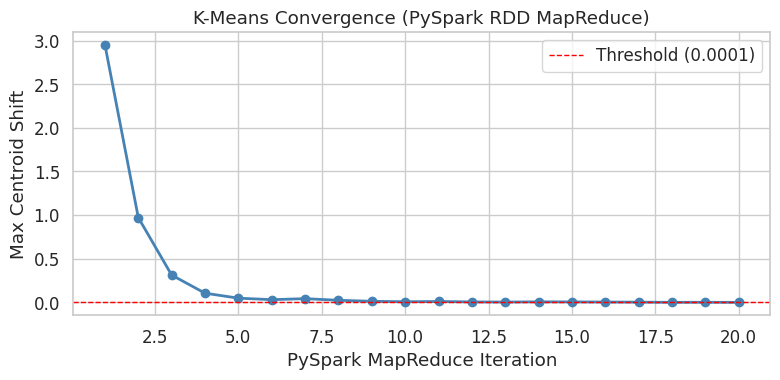

✓ Convergence curve saved


In [23]:
# ── Plot 1: Convergence curve ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(convergence_deltas) + 1), convergence_deltas,
        marker='o', color='steelblue', linewidth=2)
ax.axhline(CONVERGENCE, color='red', linestyle='--', linewidth=1,
           label=f'Threshold ({CONVERGENCE})')
ax.set_xlabel('PySpark MapReduce Iteration')
ax.set_ylabel('Max Centroid Shift')
ax.set_title('K-Means Convergence (PySpark RDD MapReduce)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/convergence_curve.png', dpi=150)
plt.show()
print("✓ Convergence curve saved")

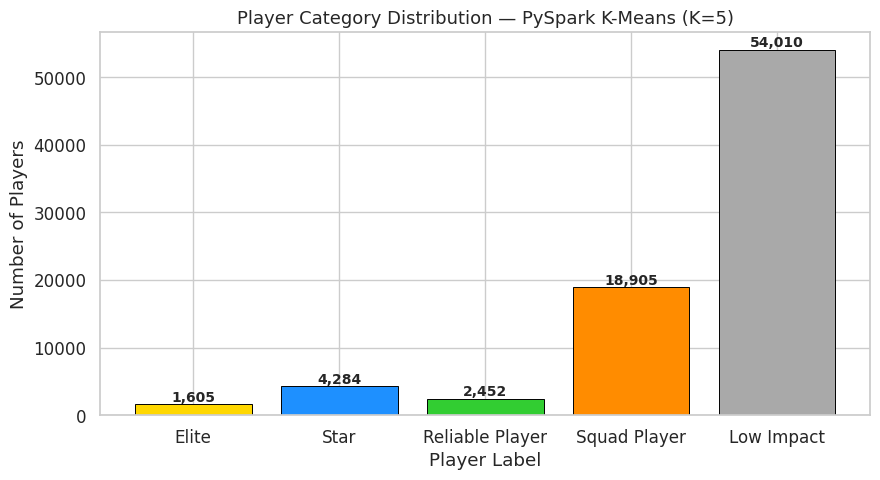

✓ Label distribution saved


In [24]:
# ── Plot 2: Label distribution ────────────────────────────────────────────────
counts = final_df['player_label'].value_counts().reindex(label_order)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values,
              color=[LABEL_COLORS[l] for l in counts.index],
              edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Player Category Distribution — PySpark K-Means (K=5)', fontsize=13)
ax.set_xlabel('Player Label')
ax.set_ylabel('Number of Players')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/label_distribution.png', dpi=150)
plt.show()
print("✓ Label distribution saved")

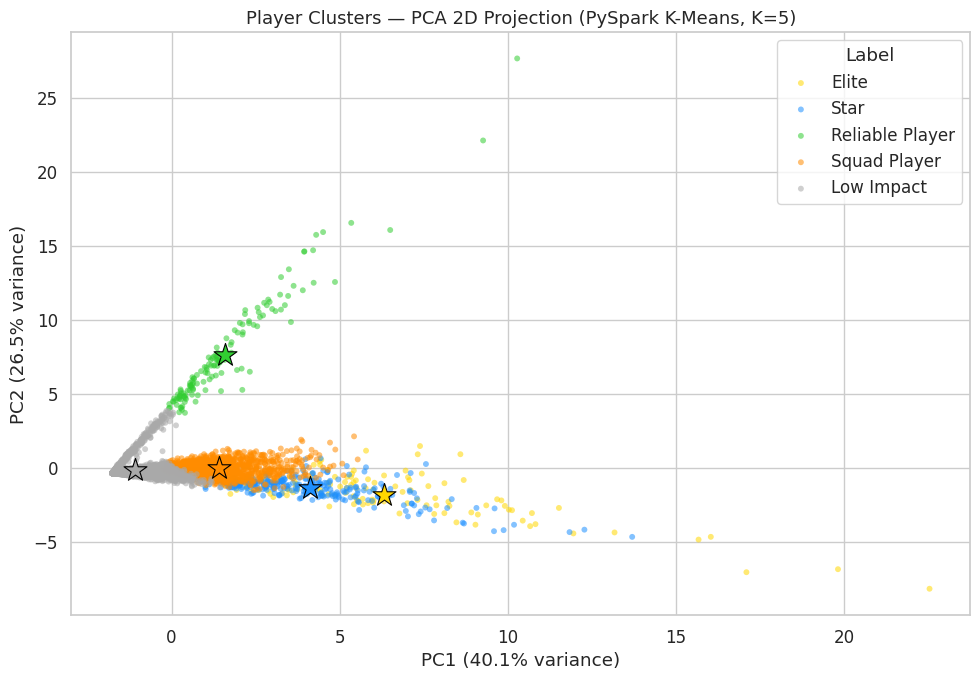

✓ PCA scatter saved


In [25]:
# ── Plot 3: PCA 2-D scatter ───────────────────────────────────────────────────
pca       = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(data_points)

plot_df = pd.DataFrame({
    'PC1':   pca_coords[:, 0],
    'PC2':   pca_coords[:, 1],
    'label': result_df['player_label'].values
})
sample = plot_df.sample(min(5_000, len(plot_df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
for lbl in label_order:
    mask = sample['label'] == lbl
    ax.scatter(sample.loc[mask, 'PC1'], sample.loc[mask, 'PC2'],
               c=LABEL_COLORS[lbl], label=lbl, alpha=0.55, s=18, edgecolors='none')

# Plot centroids
centroid_arr = np.array(final_centroids)
centroid_pca = pca.transform(centroid_arr)
for cid, (cx, cy) in enumerate(centroid_pca):
    lbl = LABEL_MAP[cid]
    ax.scatter(cx, cy, marker='*', s=300, c=LABEL_COLORS[lbl],
               edgecolors='black', linewidth=0.8, zorder=5)

ax.set_title(f'Player Clusters — PCA 2D Projection (PySpark K-Means, K=5)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Label')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_cluster_scatter.png', dpi=150)
plt.show()
print("✓ PCA scatter saved")

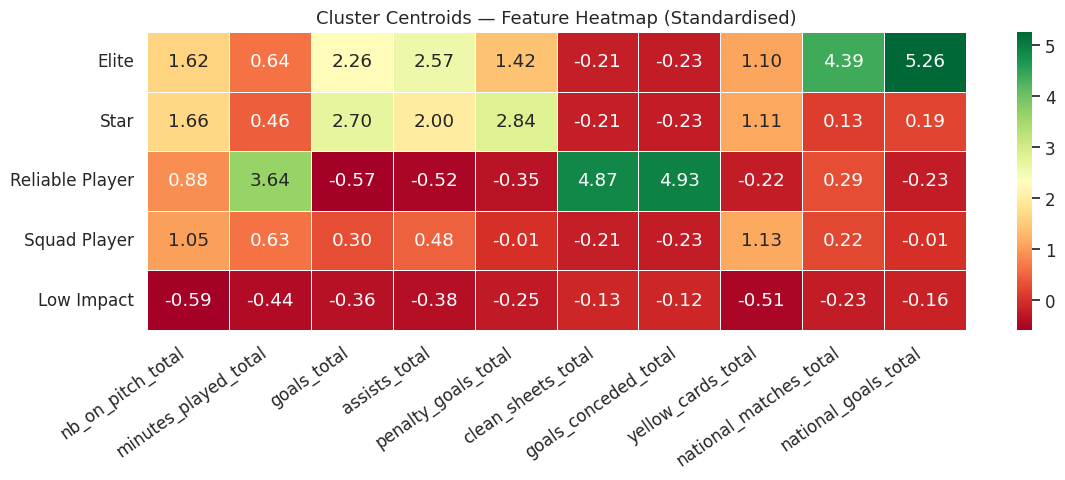

✓ Centroid heatmap saved


In [26]:
# ── Plot 4: Centroid heatmap ──────────────────────────────────────────────────
centroid_df = pd.DataFrame(final_centroids, columns=CLUSTERING_FEATURES)
centroid_df.index = [LABEL_MAP[i] for i in range(K)]
centroid_df = centroid_df.loc[label_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(centroid_df, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax)
ax.set_title('Cluster Centroids — Feature Heatmap (Standardised)', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/centroid_heatmap.png', dpi=150)
plt.show()
print("✓ Centroid heatmap saved")

In [28]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 58)
print("      PLAYER CATEGORISATION — FINAL SUMMARY")
print("=" * 58)
print(f"  Framework     : PySpark RDD MapReduce")
print(f"  K (clusters)  : {K}")
print(f"  Iterations    : {len(convergence_deltas)}")
print(f"  Total players : {len(final_df):,}")
print()
print("  Label breakdown:")
for lbl in label_order:
    n   = (final_df['player_label'] == lbl).sum()
    pct = n / len(final_df) * 100
    print(f"    {lbl:<18} {n:>6,}  ({pct:.1f}%)")
print()
print(f"  Silhouette Score     : {sil:.4f}")
print(f"  Davies-Bouldin Index : {db:.4f}")
print(f"  Calinski-Harabasz   : {ch:.1f}")
print(f"\n  Results → {RESULTS_PATH}")
print("=" * 58)

spark.stop()
print("\n✓ Spark session stopped")

      PLAYER CATEGORISATION — FINAL SUMMARY
  Framework     : PySpark RDD MapReduce
  K (clusters)  : 5
  Iterations    : 20
  Total players : 81,256

  Label breakdown:
    Elite               1,605  (2.0%)
    Star                4,284  (5.3%)
    Reliable Player     2,452  (3.0%)
    Squad Player       18,905  (23.3%)
    Low Impact         54,010  (66.5%)

  Silhouette Score     : 0.4532
  Davies-Bouldin Index : 1.1216
  Calinski-Harabasz   : 30651.0

  Results → PreProcessedData/player_categories.csv

✓ Spark session stopped
